Importing all the initial libraries required in this project 

In [93]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats


Setting start date and end date also deciding which stock we wiil be analyzing 

In [94]:
START = "2015-01-01"
END = None
TICKERS = {
    "SBI":  "SBIN.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "TCS":       "TCS.NS",
    "Nifty 50":  "^NSEI",
    "Sensex":    "^BSESN",
}
ASSET = "Sensex"


Determing the closing price of all the stocks and then put it in form of table 

In [95]:
def details(symbol):
    df = yf.download(symbol, start=START, end=END, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df["Close"].dropna()

prices = pd.DataFrame({name: details(sym) for name, sym in TICKERS.items()}).dropna()
prices.head()
    

,SBI,HDFC Bank,TCS,Nifty 50,Sensex
Date,,,,,
2015-01-02,276.019440,216.674988,983.252686,8395.450195,27887.900391
2015-01-05,273.830566,214.845627,968.309937,8378.400391,27842.320312
2015-01-06,262.579620,211.501114,932.612061,8127.350098,26987.460938
2015-01-07,262.798523,212.118393,921.595764,8102.100098,26908.820312
2015-01-08,266.913666,216.573990,931.544922,8234.599609,27274.710938


Calculating various features such as :-
one day return,
5 day return,
Volatility,
Moving Average

In [96]:
close = prices[ASSET]
feature = pd.DataFrame(index=close.index)
feature["return_1day"] = close.pct_change()
feature["return_5day"] = close.pct_change(5)
feature["ma_gap"] = close.rolling(10).mean() / close.rolling(50).mean() - 1
feature["volatility"] = feature["return_1day"].rolling(10).std()

FEATURES = ["return_1day", "return_5day", "ma_gap", "volatility"]
feature[FEATURES].tail()



,return_1day,return_5day,ma_gap,volatility
Date,,,,
2026-09-28,-0.015211,-0.027883,-0.032066,0.008675
2026-09-29,-0.003334,-0.026835,-0.032683,0.008254
2026-09-30,-0.000673,-0.031378,-0.033849,0.007960
2026-10-01,-0.007872,-0.022708,-0.035774,0.008087
2026-10-05,0.006574,-0.020478,-0.037269,0.008638


Based on change in closing price , we created target column in which '1' represent increase in prices while '0' represent decrease in prices

In [97]:
feature["target"] = (close.shift(-1) > close).astype(int)
feature["fwd_return"] = close.shift(-1) / close - 1

data = feature.dropna(subset=FEATURES + ["target"]).copy()
data.head(15)


,return_1day,return_5day,ma_gap,volatility,target,fwd_return
Date,,,,,,
2015-03-17,0.010503,0.000923,0.008856,0.009932,0,-0.003976
2015-03-18,-0.003976,-0.001293,0.004952,0.009625,0,-0.005326
2015-03-19,-0.005326,-0.015926,0.001338,0.009558,0,-0.007327
2015-03-20,-0.007327,-0.008498,-0.003685,0.009436,0,-0.002444
2015-03-23,-0.002444,-0.008640,-0.006845,0.007460,0,-0.001075
2015-03-24,-0.001075,-0.019998,-0.009363,0.007417,0,-0.001772
2015-03-25,-0.001772,-0.017828,-0.011715,0.007417,0,-0.023273
2015-03-26,-0.023273,-0.035550,-0.016745,0.008916,1,0.000039
2015-03-27,0.000039,-0.028394,-0.020398,0.008359,1,0.018836


In this first data was divided in X and Y and then data was split into test data and training data , with test data being 20% of total data

We applied two models namely, Logistic regression and Random Forest 

For both the models following things were calculated: - 

Confusion Matrix

Accuracy Score

Precision Score

F1 Score

Recall Score

In [98]:
from sklearn.model_selection import train_test_split

X = data[FEATURES]
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [99]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)   
X_test_sc = sc.transform(X_test)

In [100]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(random_state=0)
LR.fit(X_train_sc, y_train)

y_pred = LR.predict(X_test_sc)

In [101]:
comparision = pd.DataFrame({"predicted (LR)" : y_pred , "Actual": y_test.to_numpy()} , index= y_test.index)
comparision.head()

,predicted (LR),Actual
Date,,
2024-06-18,1,1
2024-06-19,1,1
2024-06-20,1,0
2024-06-21,1,1
2024-06-24,1,1


In [102]:
# below is for logistic regression

In [103]:
from sklearn.metrics import  accuracy_score

majority_class = y_train.mode()[0]
baseline_pred = np.full_like(y_test, fill_value=majority_class)
baseline_acc = accuracy_score(y_test, baseline_pred)

In [104]:
from sklearn.metrics import  accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import   recall_score
from sklearn.metrics import  f1_score
from sklearn.metrics import confusion_matrix


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
matrix = confusion_matrix(y_test , y_pred)

In [105]:
print("Confusion matrix (Logistic regression) :- " )
print(matrix)
print("Baseline Accuracy" , baseline_acc)
print("precision (Logistic regression)  =" , prec)
print("Recall (Logistic regression)     =" , rec)
print("F1 score (Logistic regression)   =" , f1)
print("accuracy (Logistic regression)   =" , acc)


Confusion matrix (Logistic regression) :- 
[[ 10 282]
 [ 15 262]]
Baseline Accuracy 0.4868189806678383
precision (Logistic regression)  = 0.48161764705882354
Recall (Logistic regression)     = 0.9458483754512635
F1 score (Logistic regression)   = 0.6382460414129111
accuracy (Logistic regression)   = 0.4780316344463972


In [106]:
# below is for random forest
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=30, class_weight="balanced", random_state=0, n_jobs=-1)
RF.fit(X_train_sc, y_train)
y_pred_rf = RF.predict(X_test_sc)                           

In [107]:
from sklearn.metrics import  accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import   recall_score
from sklearn.metrics import  f1_score
from sklearn.metrics import confusion_matrix


acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
matrix_rf = confusion_matrix(y_test , y_pred_rf)

In [108]:
print("Confusion matrix (random forest) :-" )
print(matrix_rf)
print("precision (random forest)  =" , prec_rf)
print("Recall (random forest)     =" , rec_rf)
print("F1 score (random forest)   =" , f1_rf)
print("accuracy (random forest)   =" , acc_rf)

Confusion matrix (random forest) :-
[[177 115]
 [154 123]]
precision (random forest)  = 0.5168067226890757
Recall (random forest)     = 0.44404332129963897
F1 score (random forest)   = 0.47766990291262135
accuracy (random forest)   = 0.5272407732864675


In [109]:
comparision_rf = pd.DataFrame({"predicted (RF)" : y_pred_rf , "Actual": y_test.to_numpy()} , index= y_test.index)
comparision_rf.head()

,predicted (RF),Actual
Date,,
2024-06-18,1,1
2024-06-19,0,1
2024-06-20,0,0
2024-06-21,0,1
2024-06-24,0,1


In [110]:



merged = data.join(
    comparision,
    how="inner")
merged = merged.drop(columns="target")
merged.head()

,return_1day,return_5day,ma_gap,volatility,fwd_return,predicted (LR),Actual
Date,,,,,,,
2024-06-18,0.004005,0.010603,0.020120,0.023310,0.000472,1,1
2024-06-19,0.000472,0.011523,0.026234,0.011084,0.001828,1,1
2024-06-20,0.001828,0.011388,0.029494,0.006882,-0.003472,1,0
2024-06-21,-0.003472,0.005195,0.031539,0.006995,0.001699,1,1
2024-06-24,0.001699,0.004524,0.031689,0.002385,0.009212,1,1


In [111]:
merged_2 = data.join(
    comparision_rf,
    how="inner")
merged_2 = merged_2.drop(columns="target")

merged_2.head()

,return_1day,return_5day,ma_gap,volatility,fwd_return,predicted (RF),Actual
Date,,,,,,,
2024-06-18,0.004005,0.010603,0.020120,0.023310,0.000472,1,1
2024-06-19,0.000472,0.011523,0.026234,0.011084,0.001828,0,1
2024-06-20,0.001828,0.011388,0.029494,0.006882,-0.003472,0,0
2024-06-21,-0.003472,0.005195,0.031539,0.006995,0.001699,0,1
2024-06-24,0.001699,0.004524,0.031689,0.002385,0.009212,0,1


In this value of one lakh rupees was calculated for every day using logistic regression , random forest model 

Also, value of one lakh rupees was calculated using buy and hold method (Actual), where we stay invested in the stocks irrespectvie whether there is profit or loss.

We have drawn graph comparing actual growth and ML growth (LR and RF)

In [112]:
INITIAL_CASH2 = 1_00_000

merged['strategy_return (LR)'] = merged['predicted (LR)'] * merged['fwd_return']
merged['portfolio_value (LR)'] = INITIAL_CASH2 * (1 + merged['strategy_return (LR)']).cumprod()

merged['portfolio_value (LR)'] 

Date
2024-06-18    100047.157293
2024-06-19    100229.995393
2024-06-20     99881.965277
2024-06-21    100051.664826
2024-06-24    100973.313985
                  ...      
2026-09-28     91556.848372
2026-09-29     91556.848372
2026-09-30     91556.848372
2026-10-01     91556.848372
2026-10-05              NaN
Name: portfolio_value (LR), Length: 569, dtype: float64

In [113]:
INITIAL_CASH3 = 1_00_000

merged['strategy_return (actual)'] = merged['fwd_return']
merged['portfolio_value (actual)'] = INITIAL_CASH3 * (1 + merged['strategy_return (actual)']).cumprod()

merged['portfolio_value (actual)'] 

Date
2024-06-18    100047.157293
2024-06-19    100229.995393
2024-06-20     99881.965277
2024-06-21    100051.664826
2024-06-24    100973.313985
                  ...      
2026-09-28     93826.649550
2026-09-29     93763.544078
2026-09-30     93025.410160
2026-10-01     93636.999616
2026-10-05              NaN
Name: portfolio_value (actual), Length: 569, dtype: float64

In [114]:
INITIAL_CASH4 = 1_00_000

merged_2['strategy_return (RF)'] = merged_2['predicted (RF)'] * merged['fwd_return']
merged_2['portfolio_value (RF)'] = INITIAL_CASH4 * (1 + merged_2['strategy_return (RF)']).cumprod()

merged_2['portfolio_value (RF)']

Date
2024-06-18    100047.157293
2024-06-19    100047.157293
2024-06-20    100047.157293
2024-06-21    100047.157293
2024-06-24    100047.157293
                  ...      
2026-09-28    104885.453992
2026-09-29    104814.910642
2026-09-30    104814.910642
2026-10-01    105504.009395
2026-10-05              NaN
Name: portfolio_value (RF), Length: 569, dtype: float64

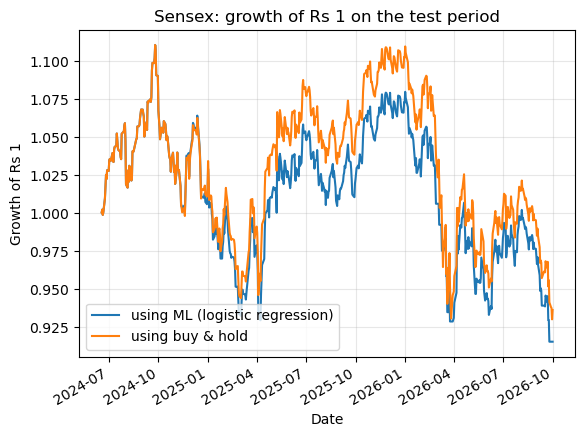

In [115]:
import matplotlib.pyplot as plt

curves = pd.DataFrame({"using ML (logistic regression)": merged['portfolio_value (LR)']  /1_00_000, "using buy & hold":merged['portfolio_value (actual)']/1_00_000
     
})
curves.plot(title=f"{ASSET}: growth of Rs 1 on the test period")
plt.ylabel("Growth of Rs 1"); plt.grid(alpha=0.3); plt.show()

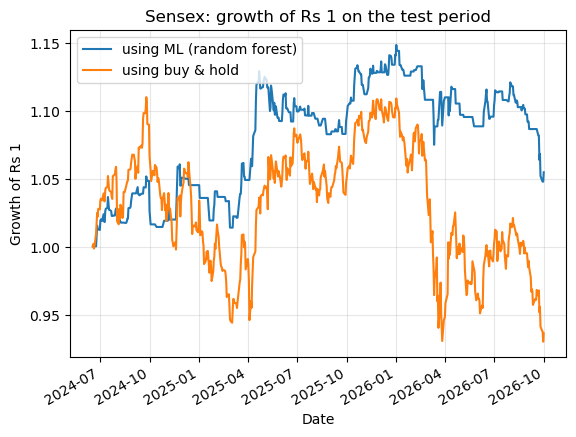

In [116]:
import matplotlib.pyplot as plt

curves = pd.DataFrame({"using ML (random forest)": merged_2['portfolio_value (RF)']  /1_00_000, "using buy & hold":merged['portfolio_value (actual)']/1_00_000
     
})
curves.plot(title=f"{ASSET}: growth of Rs 1 on the test period")
plt.ylabel("Growth of Rs 1"); plt.grid(alpha=0.3); plt.show()

for stock each terms were calculated :=

Annual Return	

Annual Volatility

Sharpe

Maximum Drawdown

In [117]:
RISK_FREE = 0.065


def summarize(r):
    ann_ret = (1 + r).prod() ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (ann_ret - RISK_FREE) / ann_vol if ann_vol > 0 else np.nan
    equity = (1 + r).cumprod()
    mdd = (equity / equity.cummax() - 1).min()
    return pd.Series({"Annual Return": ann_ret, "Annual Volatility": ann_vol, "Sharpe": sharpe, "Max Drawdown": mdd})

pd.DataFrame({"ML Strategy (LR)": summarize(merged['strategy_return (LR)']), "Buy & Hold": summarize(merged['fwd_return']) ,"ML Strategy (RF)":summarize(merged_2['strategy_return (RF)']) }).round(3)

,ML Strategy (LR),Buy & Hold,ML Strategy (RF)
Annual Return,-0.038,-0.029,0.024
Annual Volatility,0.124,0.130,0.075
Sharpe,-0.830,-0.723,-0.547
Max Drawdown,-0.175,-0.162,-0.088


Risk Analysis

for stock each terms were calculated :=

Annual Volatility	

Maximum Drawdown

Historical VaR 99%

Parametric VaR 99%

CVaR 99%

In [118]:
returns_all = prices.pct_change().dropna()

def historical_var(r, conf):
    return -np.percentile(r, (1 - conf) * 100)

def parametric_var(r, conf):
    return -(r.mean() + stats.norm.ppf(1 - conf) * r.std())

def cvar(r, conf):
    v = historical_var(r, conf)
    return -r[r <= -v].mean()

risk_rows = []
for name in returns_all.columns:
    r = returns_all[name]
    risk_rows.append({
        "Asset": name,
        "Annual Volatility": r.std() * np.sqrt(252),
        "Maximum Drawdown": ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min(),
        "Historical VaR 99%": historical_var(r, 0.99),
        "Parametric VaR 99%": parametric_var(r, 0.99),
        "CVaR 99%": cvar(r, 0.99),
    })
risk_table = pd.DataFrame(risk_rows).set_index("Asset")
risk_table.round(4)

,Annual Volatility,Maximum Drawdown,Historical VaR 99%,Parametric VaR 99%,CVaR 99%
Asset,,,,,
SBI,0.3244,-0.5949,0.0522,0.0469,0.0697
HDFC Bank,0.2235,-0.4105,0.0364,0.0322,0.0550
TCS,0.2390,-0.5339,0.0398,0.0346,0.0536
Nifty 50,0.1617,-0.3844,0.0265,0.0233,0.0434
Sensex,0.1627,-0.3807,0.0262,0.0235,0.0437
